# Handwritten Character Recognition

A deep learning project that recognizes handwritten characters using a Convolutional Neural Network (CNN).

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

## 2. Dataset Loading and Understanding

In [3]:
# Load the MNIST handwritten digit dataset

from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3. Exploratory Data Analysis

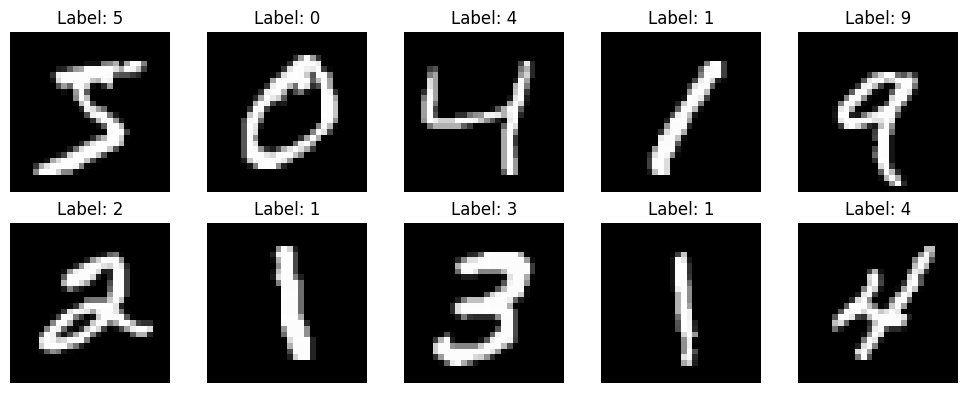

In [4]:
# Display sample handwritten digits

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [5]:
# Normalize pixel values to the range 0–1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Preprocessed training shape:", X_train.shape)
print("Preprocessed testing shape:", X_test.shape)
print("Pixel value range:", X_train.min(), "to", X_train.max())

Preprocessed training shape: (60000, 28, 28, 1)
Preprocessed testing shape: (10000, 28, 28, 1)
Pixel value range: 0.0 to 1.0


## 5. CNN Model Building

In [6]:
# Build the Convolutional Neural Network

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\zaraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training

In [7]:
# Train the CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9032 - loss: 0.3155 - val_accuracy: 0.9798 - val_loss: 0.0657
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9702 - loss: 0.1005 - val_accuracy: 0.9877 - val_loss: 0.0463
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9788 - loss: 0.0707 - val_accuracy: 0.9890 - val_loss: 0.0397
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9820 - loss: 0.0590 - val_accuracy: 0.9905 - val_loss: 0.0321
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9848 - loss: 0.0492 - val_accuracy: 0.9905 - val_loss: 0.0307
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9874 - loss: 0.0415 - val_accuracy: 0.9917 - val_loss: 0.0314
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9883 - loss: 0.0386 - val_accuracy: 0.9927 - val_loss: 0.0303
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9897 - loss: 0.0332 - val_a

## 7. Model Evaluation

In [8]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9924 - loss: 0.0234
Test Loss: 0.0234
Test Accuracy: 0.9924


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
[[ 976    0    1    0    0    0    0    2    1    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0    1 1029    0    0    0    0    2    0    0]
 [   0    0    0 1006    0    3    0    0    1    0]
 [   0    1    1    0  969    0    5    0    1    5]
 [   1    0    0    4    0  884    1    0    1    1]
 [   2    2    0    0    1    4  949    0    0    0]
 [   0    2    4    1    0    0    0 1019    1    1]
 [   1    0    2    1    0    2    0    2  964    2]
 [   0    3    0    1    1    5    1    4    1  993]]


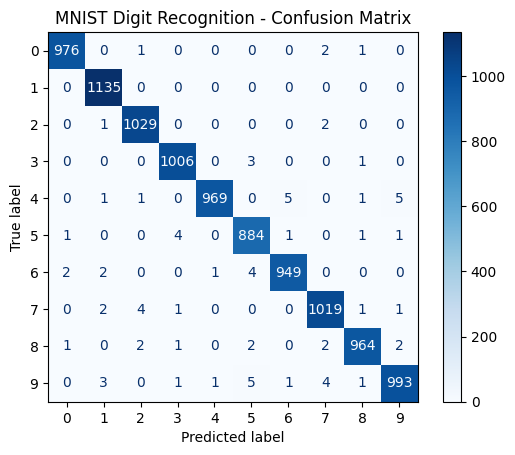

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(cmap="Blues")
plt.title("MNIST Digit Recognition - Confusion Matrix")
plt.show()

## 8. Model Saving

In [10]:
# Save the trained CNN model
model.save("../models/handwritten_character_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


## 9. Handwritten Digit Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


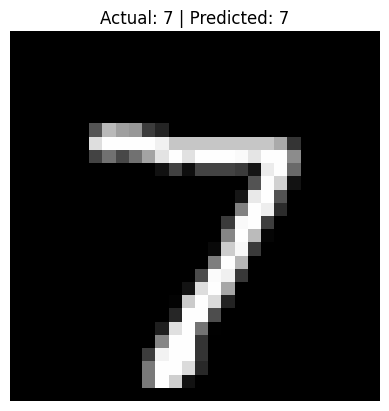

Actual Digit: 7
Predicted Digit: 7


In [11]:
# Predict a sample image from the test dataset

sample_index = 0

sample_image = X_test[sample_index]
actual_label = y_test[sample_index]

prediction = model.predict(sample_image.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
plt.axis("off")
plt.show()

print("Actual Digit:", actual_label)
print("Predicted Digit:", predicted_label)

## 10. Final Model Results

In [12]:
print("Final Model Results")
print("-------------------")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print("Model: Convolutional Neural Network (CNN)")
print("Dataset: MNIST")

Final Model Results
-------------------
Test Accuracy: 99.24%
Test Loss: 0.0234
Model: Convolutional Neural Network (CNN)
Dataset: MNIST
